In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import plotly.graph_objects as go
import plotly.io as pio
from pymoo.indicators.hv import HV
from pymoo.mcdm.pseudo_weights import PseudoWeights

from utils import plot_generational_metrics_interactive, plot_pareto_front, plot_pareto_front_matplot, plot_hypervolume_evolution, plot_pareto_front_with_solutions, build_representative_summary, plot_representative_chord, plot_representative_pitch

In [2]:
# base_path = Path("../results/p200g100_12_02")
base_path = Path("../results/p500g150_2026-01-29")

In [3]:
evaluations_path = base_path / "evaluations.csv"
pareto_path = base_path / "pareto_front.csv"
representatives_path = base_path / "pareto_front_representatives.csv"

# Importa os CSVs
df_evaluations = pd.read_csv(evaluations_path)
df_pareto = pd.read_csv(pareto_path)
df_representatives = pd.read_csv(representatives_path)

In [4]:
pio.renderers.default = "browser"  # ou "svg", "png", "json", etc.

fig = plot_generational_metrics_interactive(df_evaluations)
fig.show()

In [5]:
pio.renderers.default = "browser"  # se estiver fora de Jupyter

fig = plot_pareto_front(df_pareto)
fig.show()

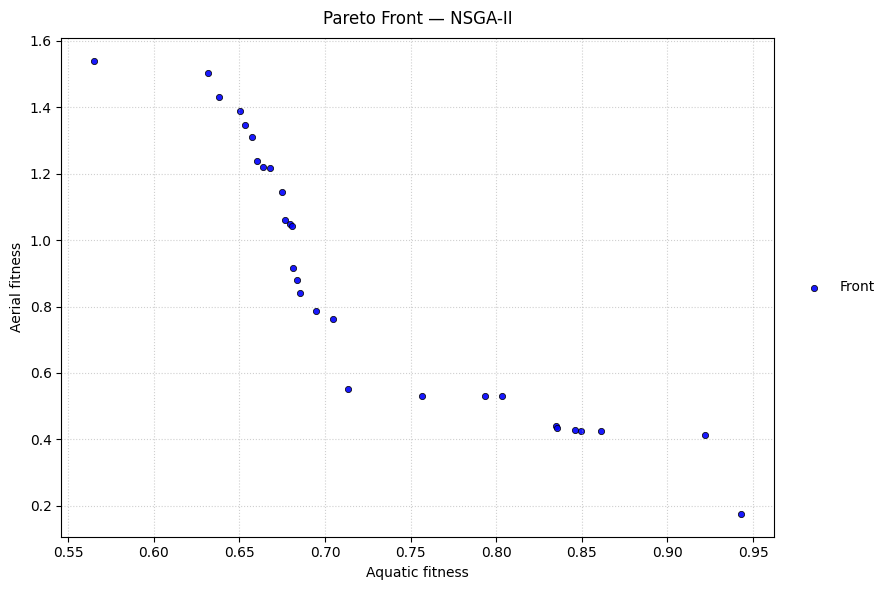

In [6]:
plot_pareto_front_matplot(df_pareto)

In [7]:
generations = sorted(df_evaluations['generation'].unique())
hv_values = []

# O ponto de referência deve ser [min_f1, min_f2]. 
# Como buscamos maximizar Fitness, usamos [0, 0] ou um pouco menos.
ref_point = np.array([0.0, 0.0]) 
ind = HV(ref_point=ref_point)

for gen in generations:
    gen_data = df_evaluations[df_evaluations['generation'] == gen][['aerial_fitness', 'aquatic_fitness']].values
    gen_data = gen_data * -1  # Inverter os sinais para maximizar
    hv_values.append(ind.do(gen_data))

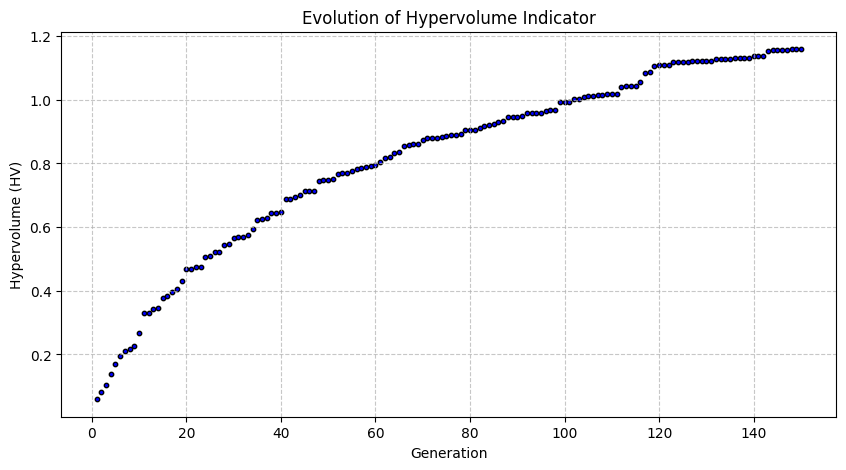

In [8]:
plot_hypervolume_evolution(generations, hv_values)

In [9]:
# negativo na frente para tornar o problema de maximização em minimização, que é o formato esperado pelo PseudoWeights
F = -df_pareto[['aerial_fitness', 'aquatic_fitness']].to_numpy()
weights = np.array([0.5, 0.5])

intermediate_representative_idx = PseudoWeights(weights).do(F)


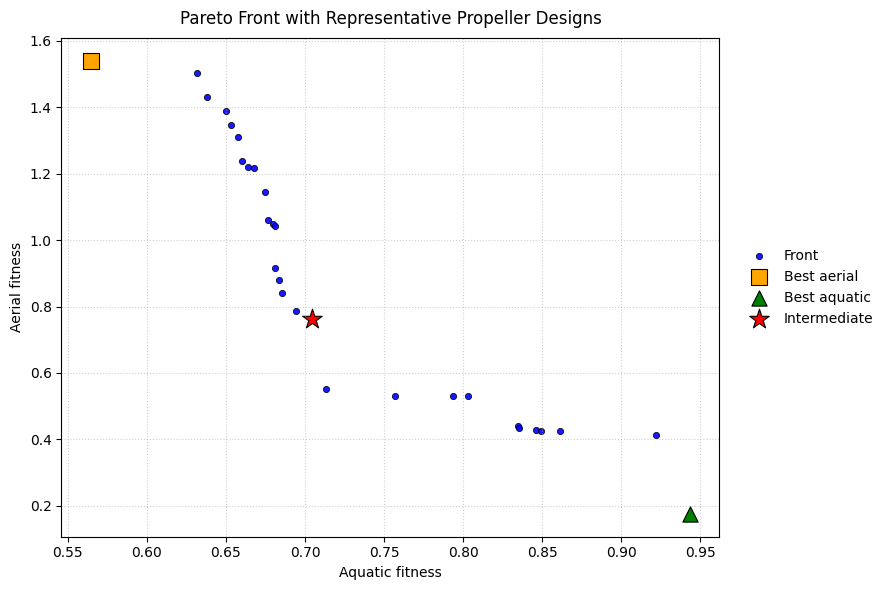

In [10]:
plot_pareto_front_with_solutions(df_pareto, intermediate_representative_idx)

In [11]:
x = df_pareto['aquatic_fitness'].to_numpy()
y = df_pareto['aerial_fitness'].to_numpy()

best_aerial_pos = np.argmax(y)
best_aquatic_pos = np.argmax(x)

In [12]:
# print(df_pareto.iloc[best_aerial_pos])

In [13]:
# print(df_pareto.iloc[intermediate_representative_idx])

In [ ]:

# print(df_pareto.iloc[best_aquatic_pos])

In [17]:
summary = build_representative_summary(df_representatives)
print(summary)

         Design  Blades  Aerial fitness  Aquatic fitness  Mean chord [m]  \
0   Best aerial       2        1.540984         0.564881        0.028607   
1  Intermediate       4        0.762196         0.704482        0.015593   
2  Best aquatic       5        0.175056         0.943262        0.022572   

   Max chord [m]  Mean pitch [deg]                Airfoils  
0       0.040524          9.149147                E63 (20)  
1       0.023528          8.651897  NACA4412 (1), E63 (19)  
2       0.033812          8.374803                E63 (20)  
